# Рекомендации против оттока для маркетплейса Neon

## Задача

Neon теряет много клиентов: из тех, кто заказывал в последние два месяца, почти половина не возвращается в следующий месяц.
Хотим понять, может ли рекомендательная система помочь их удержать.

Идея: человек остаётся, если заказывать удобно и есть что-то интересное. Рекомендации могут помочь и с тем, и с другим:
- **"Купить снова"** - повысить лояльность за счет персонализации;
- **"С этим товаром покупают", "Похожие товары" и "Вам также может понравиться"** - подсказать, что ещё интересного можно взять.

**Данные:** [YSDA RecSys 2025 - Lavka](https://www.kaggle.com/datasets/thekabeton/ysda-recsys-2025-lavka-dataset) - действия пользователей Лавки примерно за 13 месяцев.

In [1]:
import datetime as dt
import itertools
import pathlib

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight
from scipy.stats import norm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams["figure.figsize"] = (12, 4)

DAY = 24 * 60 * 60  # timestamp в данных - секунды Unix
SEED = 42
DATA = pathlib.Path(kagglehub.dataset_download("thekabeton/ysda-recsys-2025-lavka-dataset"))

## 1. Данные

In [2]:
raw = pl.scan_parquet(DATA / "train.parquet")

In [3]:
raw.head().collect()

action_type,city_name,position_in_request,product_category,product_id,product_image,product_name,request_id,source_type,store_id,timestamp,user_id
str,str,i64,str,u64,str,str,u64,str,u64,i64,u64
"""AT_View""","""Екатеринбург""",20,"""Колбаса сырокопченая/сыровяленная нарезка""",15622873057108008619,"""https://avatars.mds.yandex.net/get-grocery-goods/2791769/d42…","""Колбаса сервелат-салями Элитная-Брауншвейгская «Велес» ассор…",9541715973781753063,"""ST_Search""",14539184420433789706,1692527447,7421231689159170748
"""AT_View""","""Москва""",68,"""ПАСТА С МЯСОМ ПТИЦЫ""",17225686928570569253,"""https://avatars.mds.yandex.net/get-grocery-goods/2756334/12b…","""Паста с куриной грудкой в сливочном соусе песто «Из Лавки», …",8471250031114211515,"""ST_Search""",14058715110002771508,1686479624,135364936461809128
"""AT_View""","""Москва""",8,"""Бумажные полотенца""",9571392871249924586,"""https://avatars.mds.yandex.net/get-grocery-goods/2756334/52a…","""Полотенца бумажные Zewa, 4 шт.""",16057244839195726423,"""ST_SearchStartRec""",9463368652572089691,1691202307,7846147652438475366
"""AT_Purchase""","""Нижний Новгород""",null,"""КОТЛЕТА МЯСНАЯ С ОВОЩАМИ""",2281275230546064866,"""https://avatars.mds.yandex.net/get-grocery-goods/2783132/8c8…","""Котлета нежная с гречкой и овощами «Кулинария Ирины Князевой…",null,null,4220451351681881198,1683883091,365744836962066469
"""AT_View""","""Москва""",37,"""Сок яблочный восстановленный от 0,5л""",6458244614391609220,"""https://avatars.mds.yandex.net/get-grocery-goods/2756334/fc6…","""Напиток сокосодержащий Яблоко «Любимый» осветлённый, 1.93 л""",11838631385573779102,"""ST_Search""",4666210310211554321,1691893320,13306396713639957054


In [4]:
raw.select(
    pl.len().alias("события"),
    pl.col("user_id").n_unique().alias("пользователи"),
    pl.col("product_id").n_unique().alias("товары"),
    pl.col("store_id").n_unique().alias("уникальные магазины"),
    pl.col("city_name").n_unique().alias("города"),
).collect()

события,пользователи,товары,уникальные магазины,города
u32,u32,u32,u32,u32
16508614,3550,26522,627,12


### Колонки

| Колонка | Описание |
|---|---|
| `user_id` | айди пользователя |
| `product_id` | айди товара |
| `product_name` | название товара |
| `product_category` | категория товара |
| `product_image` | ссылка на картинку товара |
| `action_type` | тип действия |
| `source_type` | в каком блоке приложения произошло действие |
| `request_id` | идентификатор выдачи: один показ страницы, поиска или карусели |
| `position_in_request` | позиция товара в этой выдаче |
| `store_id` | магазин, из которого собирается заказ |
| `city_name` | город |
| `timestamp` | время события в секундах Unix (отсюда `DAY = 24 * 60 * 60`) |

**`action_type` - что сделал пользователь:**

| Значение | Описание |
|---|---|
| `AT_View` | показ товара в выдаче |
| `AT_Click` | клик на товар |
| `AT_CartUpdate` | изменение товара в корзине |
| `AT_Purchase` | покупка |

**`source_type` - где это произошло:**

| Значение | Блок |
|---|---|
| `ST_Catalog` | каталог |
| `ST_Search` | результаты поиска |
| `ST_Feed` | лента на главной |
| `ST_Upsale`, `ST_CheckoutUpsale` | допродажа: "добавьте к заказу", в том числе при оформлении |
| `ST_ItemPageCarousel` | карусель на странице товара |
| `ST_SearchComplementRec`, `ST_SearchStartRec` | рекомендации в поиске: дополняющие к запросу и до начала ввода |
| `ST_PreviousBuyHub`, `ST_PreviousBuyCarousel` | "Вы покупали" - раздел и карусель |
| `ST_Uplift` | промо-подборка |
| `ST_OnClickDelivery` | быстрый заказ в один клик |

## 2. Какие колонки понадобятся

Главный сигнал для рекомендаций - покупка.  
Для простоты реализации показы и клики не берём.

| Колонка | Зачем берём |
|---|---|
| `user_id`, `product_id` | кто и что купил |
| `action_type` | оставить только покупки |
| `timestamp` | когда: для разреза по времени и учёта давности |
| `product_name`, `product_category` | справочник товаров: для content-based и примеров |

Отдельного номера заказа в данных нет, поэтому заказом будем считать все покупки одного пользователя с одинаковым временем.

In [5]:
catalog = raw.group_by("product_id").agg(pl.col("product_name").first(), pl.col("product_category").first()).collect()

# заказ = покупки одного пользователя с одним timestamp
purchases = (
    raw.filter((pl.col("action_type") == "AT_Purchase") & ~pl.col("product_name").str.contains("(?i)пакет"))
    .select("user_id", "product_id", "timestamp")
    .unique()
    .sort("timestamp", "user_id", "product_id")  # фиксируем порядок для воспроизводимости
    .collect()
)

orders = purchases.group_by("user_id", "timestamp").len("basket_size").sort("timestamp", "user_id")
purchases = purchases.join(orders.with_row_index("order_id").select("user_id", "timestamp", "order_id"),
                           on=["user_id", "timestamp"]).sort("timestamp", "user_id", "product_id")

print(f"покупателей: {orders['user_id'].n_unique()}, заказов: {orders.height}, позиций: {purchases.height}, "
      f"медиана корзины: {orders['basket_size'].median():.0f}")

покупателей: 1847, заказов: 35828, позиций: 202549, медиана корзины: 4


### Посмотрим на отток

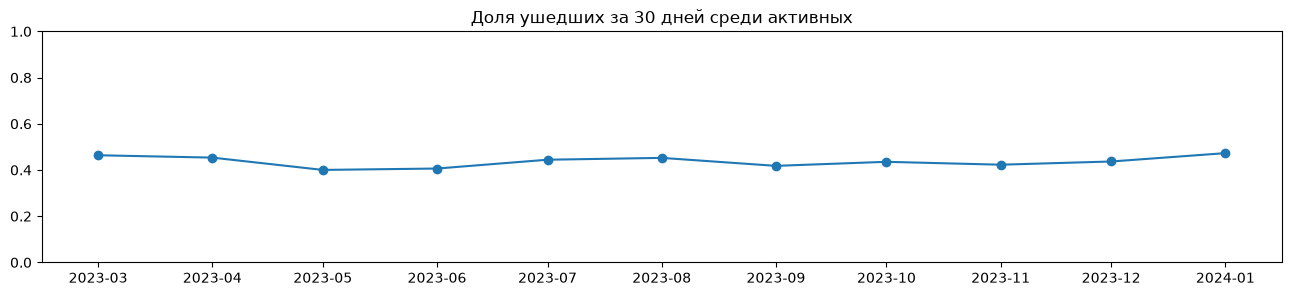

date,active_users,churn_rate
"datetime[μs, UTC]",i64,f64
2023-03-01 00:00:00 UTC,649,0.464
2023-04-01 00:00:00 UTC,657,0.454
2023-05-01 00:00:00 UTC,637,0.4
2023-06-01 00:00:00 UTC,635,0.406
2023-07-01 00:00:00 UTC,675,0.444
2023-08-01 00:00:00 UTC,683,0.452
2023-09-01 00:00:00 UTC,682,0.418
2023-10-01 00:00:00 UTC,735,0.435
2023-11-01 00:00:00 UTC,778,0.423


In [6]:
ACTIVE_DAYS, CHURN_DAYS = 60, 30

def churn_at(x):
    t = int(x.timestamp())
    active = orders.filter(pl.col("timestamp").is_between(t - ACTIVE_DAYS * DAY, t, closed="left"))["user_id"].unique()
    back = orders.filter(pl.col("timestamp").is_between(t, t + CHURN_DAYS * DAY, closed="left"))["user_id"].unique()
    return {"date": x, "active_users": len(active), "churn_rate": 1 - len(set(active) & set(back)) / len(active)}


churn = pl.DataFrame([churn_at(x) for x in pl.datetime_range(
    dt.datetime(2023, 3, 1), dt.datetime(2024, 1, 1), "1mo", eager=True, time_zone="UTC")])
plt.figure(figsize=(16, 3))
plt.plot(churn["date"], churn["churn_rate"], marker="o")
plt.title("Доля ушедших за 30 дней среди активных"); plt.ylim(0, 1); plt.show()
churn.with_columns(pl.col("churn_rate").round(3))

In [7]:
first_buy = purchases.group_by("user_id", "product_id").agg(pl.col("timestamp").min().alias("first_ts"))
repeat_share = purchases.join(first_buy, on=["user_id", "product_id"]).select(
    (pl.col("timestamp") > pl.col("first_ts")).mean()).item()
print(f"доля позиций, которые пользователь уже покупал раньше: {repeat_share:.1%}")

доля позиций, которые пользователь уже покупал раньше: 49.4%


## 3. Предсказание следующей покупки

Делим данные по времени: всё до даты разреза - история, цель - **первый заказ** пользователя в следующие 30 дней.

- **валидация** (разрез 2023-12-03) - на ней подбираем параметры: размерность ALS и веса гибрида;
- **тест** (разрез 2024-01-03) - на нём только итоговое сравнение моделей.

Окна цели не пересекаются: валидация заканчивается 2024-01-02, тест начинается 2024-01-03.

**Метрики качества модели:**
- **Recall@10** - какую долю следующего заказа мы угадали;
- **HitRate@10** - у скольких пользователей угадали хотя бы один товар;
- **NDCG@10** - то же, что Recall, но учитывает позицию: угаданный товар на первом месте ценнее, чем на десятом;
- **Coverage** - какая доля каталога вообще попадает в рекомендации. Если она маленькая, всем показывают одно и то же.

In [8]:
HORIZON_DAYS = 30
K = 10
EPS = 1e-6  # малый вклад популярности: разбивает ничьи между товарами с одинаковым скором


class Split:
    def __init__(self, cut):
        self.name = str(cut.date())
        self.cut = int(cut.timestamp())
        self.hist = purchases.filter(pl.col("timestamp") < self.cut)
        self.items = np.sort(self.hist["product_id"].unique().to_numpy())
        self.users = np.sort(self.hist["user_id"].unique().to_numpy())
        self.user_index = pl.DataFrame({"user_id": self.users, "u": np.arange(len(self.users))})
        self.item_index = pl.DataFrame({"product_id": self.items, "i": np.arange(len(self.items))})
        self.hist = self.hist.join(self.user_index, on="user_id").join(self.item_index, on="product_id")
        self.shape = (len(self.users), len(self.items))

        future = purchases.filter(pl.col("timestamp").is_between(self.cut, self.cut + HORIZON_DAYS * DAY, closed="left"))
        first = future.filter(pl.col("timestamp") == pl.col("timestamp").min().over("user_id"))
        target = first.group_by("user_id").agg(pl.col("product_id")).sort("user_id")
        warm = target.join(self.user_index, on="user_id", how="semi")
        self.n_cold = target.height - warm.height
        self.cold_gt = [set(x) for x in target.join(self.user_index, on="user_id", how="anti")["product_id"].to_list()]
        self.target_users = warm["user_id"].to_numpy()
        self.t_rows = np.searchsorted(self.users, self.target_users)
        self.gt = [set(x) for x in warm["product_id"].to_list()]

    def matrix(self, tau=None):
        """Матрица пользователь-товар: число заказов с товаром, или с затуханием exp(-давность/tau дней)."""
        w = pl.lit(1.0) if tau is None else (-(self.cut - pl.col("timestamp")) / (tau * DAY)).exp()
        h = self.hist.with_columns(w.alias("w"))
        return sp.csr_matrix((h["w"].to_numpy(), (h["u"].to_numpy(), h["i"].to_numpy())), shape=self.shape)

    def popularity(self, days=30):
        """Число покупателей товара за последние дни, нормировано на максимум."""
        c = self.hist.filter(pl.col("timestamp") >= self.cut - days * DAY).group_by("i").agg(pl.col("u").n_unique())
        v = np.zeros(len(self.items))
        v[c["i"].to_numpy()] = c["u"].to_numpy()
        return v / v.max()


def top_k(scores, k=K):
    idx = np.argpartition(-scores, k, axis=1)[:, :k]
    return np.take_along_axis(idx, np.argsort(-np.take_along_axis(scores, idx, 1), axis=1), 1)


def evaluate(scores, s, k=K, gt=None):
    gt = s.gt if gt is None else gt
    top = top_k(scores, k)
    rel = np.array([[p in g for p in s.items[row].tolist()] for row, g in zip(top, gt)])
    disc = 1 / np.log2(np.arange(2, k + 2))
    ideal = np.array([disc[:min(len(g), k)].sum() for g in gt])
    hits = rel.sum(1)
    return {f"Recall@{k}": np.mean(hits / np.array([len(g) for g in gt])),
            f"HitRate@{k}": np.mean(hits > 0),
            f"NDCG@{k}": np.mean(rel @ disc / ideal),
            "Coverage": len(np.unique(top)) / len(s.items)}


val = Split(dt.datetime(2023, 12, 3, tzinfo=dt.timezone.utc))
test = Split(dt.datetime(2024, 1, 3, tzinfo=dt.timezone.utc))
for s in (val, test):
    print(f"{s.name}: пользователей с историей в цели {len(s.t_rows)}, новых {s.n_cold}, товаров {len(s.items)}")

2023-12-03: пользователей с историей в цели 553, новых 136, товаров 10990
2024-01-03: пользователей с историей в цели 552, новых 112, товаров 11525


## 4. Модели

### 4.1. Эвристики

| Блок | Правило |
|---|---|
| **"Популярное"** | товары, которые за последние 30 дней купило больше всего людей. Одинаковое для всех, поэтому подходит новичкам |
| **"Купить снова"** | то, что человек уже покупал: чем чаще и чем недавнее, тем выше. Каждая покупка весит $e^{-\Delta t/\tau}$, где $\Delta t$ - сколько дней назад она была |

Параметр $\tau$ задаёт, как быстро "забываются" старые покупки. Берём $\tau$ = 30 дней: покупка месячной давности весит примерно втрое меньше вчерашней.

In [9]:
TAU = 30  # дней

def rec_popular(s):
    return np.tile(s.popularity(), (len(s.t_rows), 1))


def rec_buy_again(s):
    return s.matrix(TAU)[s.t_rows].toarray() + EPS * s.popularity()

### 4.2. Классические подходы

**Item-based CF - "С этим товаром покупают".** Два товара похожи, если их часто покупают в одном заказе:
$\text{sim}(i,j) = \frac{c_{ij}}{\sqrt{n_i n_j} + 5}$, где $c_{ij}$ - сколько раз товары были в одном заказе, а $n_i$ и $n_j$ - сколько раз каждый покупали.

**User-based CF - "Вам также может понравиться".** Два пользователя похожи, если покупают одно и то же: косинус между их историями (с тем же затуханием $\tau$). Для каждого берём 50 ближайших соседей и рекомендуем то, что покупали они, с весом по похожести.

**Content-based - "Похожие товары".** Рекомендуем товары, похожие по тексту на купленные: TF-IDF по символьным n-граммам названия и категории, профиль пользователя - сумма векторов его покупок.

**ALS - матричное разложение (готовая реализация из `implicit`).** Матрица пользователь-товар раскладывается на векторы пользователей и товаров, скор - их скалярное произведение. Перед обучением покупки перевзвешиваем BM25, чтобы очень популярные товары не забивали остальные. Размерность векторов подбираем на валидации.

In [10]:
def item_similarity(s, shrink=5.0):
    h = s.hist
    B = sp.csr_matrix((np.ones(h.height), (h["order_id"].rank("dense").to_numpy() - 1, h["i"].to_numpy())))
    C = (B.T @ B).tocoo()
    n = np.asarray(B.sum(0)).ravel()
    off_diag = C.row != C.col
    r, c = C.row[off_diag], C.col[off_diag]
    return sp.csr_matrix((C.data[off_diag] / (np.sqrt(n[r] * n[c]) + shrink), (r, c)), shape=(len(s.items),) * 2)


def rec_item_cf(s):
    return (s.matrix(TAU)[s.t_rows] @ item_similarity(s)).toarray() + EPS * s.popularity()


def rec_user_cf(s, n_neighbors=50):
    R = s.matrix(TAU)
    X = normalize(R)
    sim = (X[s.t_rows] @ X.T).toarray()
    sim[np.arange(len(s.t_rows)), s.t_rows] = 0  # сам себе не сосед
    far = np.argpartition(-sim, n_neighbors, axis=1)[:, n_neighbors:]
    np.put_along_axis(sim, far, 0, axis=1)
    return (sp.csr_matrix(sim) @ R).toarray() + EPS * s.popularity()


def item_text_vectors(s):
    names = pl.DataFrame({"product_id": s.items}).join(catalog, on="product_id", how="left")
    texts = (names["product_category"].fill_null("") + " " + names["product_name"].fill_null("")).str.to_lowercase()
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True).fit_transform(texts)


def rec_content(s):
    X = item_text_vectors(s)
    profile = normalize(s.matrix(TAU)[s.t_rows] @ X)
    return (profile @ X.T).toarray() + EPS * s.popularity()



def rec_als(s, factors):
    R = bm25_weight(s.matrix(TAU), K1=100, B=0.8).tocsr()
    model = AlternatingLeastSquares(factors=factors, regularization=0.05, iterations=20, random_state=SEED)
    model.fit(R, show_progress=False)
    return np.asarray(model.user_factors)[s.t_rows] @ np.asarray(model.item_factors).T + EPS * s.popularity()

In [11]:
als_grid = pl.DataFrame([{"factors": f, **evaluate(rec_als(val, f), val)} for f in (32, 64, 128, 256)])
ALS_FACTORS = als_grid.sort("Recall@10", descending=True)["factors"][0]
print("ALS: размерность", ALS_FACTORS)
als_grid.with_columns(pl.selectors.float().round(4))

ALS: размерность 128


factors,Recall@10,HitRate@10,NDCG@10,Coverage
i64,f64,f64,f64,f64
32,0.118,0.4268,0.0986,0.0773
64,0.1443,0.4774,0.1233,0.1177
128,0.157,0.5208,0.1323,0.1436
256,0.1414,0.4647,0.1145,0.1516


In [12]:
MODELS = {"popular": rec_popular, "buy_again": rec_buy_again, "item_cf": rec_item_cf,
          "user_cf": rec_user_cf, "content": rec_content, "als": lambda s: rec_als(s, ALS_FACTORS)}
scores = {m: f(test) for m, f in MODELS.items()}
results = [{"model": m, **evaluate(S, test)} for m, S in scores.items()]
pl.DataFrame(results).with_columns(pl.selectors.float().round(4))

model,Recall@10,HitRate@10,NDCG@10,Coverage
str,f64,f64,f64,f64
"""popular""",0.0257,0.1467,0.0202,0.0009
"""buy_again""",0.1686,0.5725,0.1719,0.2415
"""item_cf""",0.0999,0.4076,0.0945,0.2796
"""user_cf""",0.0751,0.3225,0.0787,0.075
"""content""",0.0981,0.3822,0.1109,0.246
"""als""",0.1454,0.5127,0.1219,0.13


### 4.3. Гибрид

Взвешенная сумма нормированных скоров: "Купить снова" с весом 1 плюс добавки от content-based, item-CF, ALS и популярного.
Веса перебираем по сетке на **валидации**. Правило выбора: среди комбинаций, у которых Recall@10 не хуже 99% от лучшего, берём ту, где больше Coverage: при почти равной точности лучше более разнообразная выдача.

In [13]:
def scale_rows(S):
    S = S - S.min(1, keepdims=True)
    return S / (S.max(1, keepdims=True) + 1e-12)


PARTS = {"content": [0, 0.05, 0.1, 0.2, 0.5], "item_cf": [0, 0.05, 0.1, 0.2, 0.5],
         "als": [0, 0.05, 0.1, 0.2, 0.5], "popular": [0, 0.05]}
val_scores = {m: scale_rows(MODELS[m](val)) for m in ["buy_again", *PARTS]}

grid = []
for w in itertools.product(*PARTS.values()):
    H = val_scores["buy_again"] + sum(wi * val_scores[m] for wi, m in zip(w, PARTS))
    grid.append({**dict(zip(PARTS, w)), **evaluate(H, val)})
grid = pl.DataFrame(grid)

best = (grid.filter(pl.col("Recall@10") >= 0.99 * grid["Recall@10"].max())
        .sort("Coverage", descending=True).row(0, named=True))
WEIGHTS = {"buy_again": 1.0, **{m: best[m] for m in PARTS if best[m] > 0}}
print("веса гибрида:", WEIGHTS)
grid.sort("Recall@10", descending=True).head(5).with_columns(pl.selectors.float().round(4))

веса гибрида: {'buy_again': 1.0, 'content': 0.05}


content,item_cf,als,popular,Recall@10,HitRate@10,NDCG@10,Coverage
f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.1852,0.5552,0.1769,0.251
0.2,0.05,0.5,0.0,0.1847,0.5479,0.1784,0.2363
0.05,0.0,0.0,0.0,0.1844,0.5461,0.1755,0.2827
0.0,0.0,0.0,0.05,0.1844,0.5552,0.1761,0.2464
0.05,0.0,0.5,0.0,0.1843,0.5461,0.1787,0.227


In [14]:
hybrid_scores = sum(w * scale_rows(scores[m]) for m, w in WEIGHTS.items())

In [15]:
results.append({"model": "hybrid", **evaluate(hybrid_scores, test)})
final = pl.DataFrame(results).sort("Recall@10", descending=True).with_columns(pl.selectors.float().round(4))
final

model,Recall@10,HitRate@10,NDCG@10,Coverage
str,f64,f64,f64,f64
"""hybrid""",0.1703,0.567,0.1733,0.2678
"""buy_again""",0.1686,0.5725,0.1719,0.2415
"""als""",0.1454,0.5127,0.1219,0.13
"""item_cf""",0.0999,0.4076,0.0945,0.2796
"""content""",0.0981,0.3822,0.1109,0.246
"""user_cf""",0.0751,0.3225,0.0787,0.075
"""popular""",0.0257,0.1467,0.0202,0.0009


In [16]:
def per_user_recall(S, s):
    return np.array([len(set(s.items[row].tolist()) & gt) / len(gt) for row, gt in zip(top_k(S), s.gt)])


rng = np.random.default_rng(SEED)
d = per_user_recall(hybrid_scores, test) - per_user_recall(scores["buy_again"], test)
boot = d[rng.integers(0, len(d), (5000, len(d)))].mean(1)
print(f'гибрид - "Купить снова": Recall@10 {d.mean():+.4f}, 95% ДИ [{np.percentile(boot, 2.5):+.4f}, {np.percentile(boot, 97.5):+.4f}]')

гибрид - "Купить снова": Recall@10 +0.0017, 95% ДИ [-0.0036, +0.0079]


### 4.4. Новые для пользователя товары

Recall поощряет повторы. Посмотрим, какую долю топ-10 каждой модели составляют товары, которые пользователь ещё не покупал.

In [17]:
bought_before = test.matrix()[test.t_rows].toarray() > 0
pl.DataFrame([{"model": m, "новые товары в топ-10": 1 - np.take_along_axis(bought_before, top_k(S), 1).mean()}
              for m, S in {**scores, "hybrid": hybrid_scores}.items()]
             ).sort("новые товары в топ-10", descending=True).with_columns(pl.selectors.float().round(3))

model,новые товары в топ-10
str,f64
"""popular""",0.855
"""user_cf""",0.624
"""content""",0.572
"""item_cf""",0.343
"""als""",0.149
"""hybrid""",0.069
"""buy_again""",0.042


### 4.5. Новые пользователи

У новичков нет истории, поэтому для них доступно только "Популярное". Сравним, насколько оно работает у них и у пользователей с историей.

In [18]:
pop_cold = np.tile(test.popularity(), (len(test.cold_gt), 1))
pl.DataFrame([
    {"пользователи": f"новые ({len(test.cold_gt)})", **evaluate(pop_cold, test, gt=test.cold_gt)},
    {"пользователи": f"с историей ({len(test.gt)})", **evaluate(scores["popular"], test)},
]).with_columns(pl.selectors.float().round(4))

пользователи,Recall@10,HitRate@10,NDCG@10,Coverage
str,f64,f64,f64,f64
"""новые (112)""",0.0273,0.1786,0.0222,0.0009
"""с историей (552)""",0.0257,0.1467,0.0202,0.0009


### Пример рекомендаций

In [19]:
product_names = dict(zip(catalog["product_id"].to_list(), catalog["product_name"].to_list()))


def show(item_idx, s):
    return pl.DataFrame({"товар": [product_names[p] for p in s.items[item_idx].tolist()]})


anchor = int(np.argmax(test.popularity()))  # самый популярный товар месяца
print("Товар:", product_names[test.items[anchor]])
sim = item_similarity(test)[anchor].toarray().ravel()
print("С этим товаром покупают:"); display(show(np.argsort(-sim)[:5], test))
X_text = item_text_vectors(test)
sim = (X_text @ X_text[anchor].T).toarray().ravel(); sim[anchor] = -1
print("Похожие товары (замены):"); display(show(np.argsort(-sim)[:5], test))

Товар: Подарочный конверт Яндекс Плюс, 1 шт.
С этим товаром покупают:


товар
str
"""Запеканка из рикотты с манго и маракуйя «Про вкус», 200 г"""
"""Трусы бразилиано женские Innamore Basic Acacia белый размер …"
"""Гирлянда светодиодная Роса Neon-Night 2 м 20 LED жёлтое свеч…"
"""Киви Gold, 500 г"""
"""Хлеб Праздничный «Рижский хлеб» с орехами и сухофруктами, 20…"


Похожие товары (замены):


товар
str
"""Умный пульт Яндекса, 1 шт."""
"""Подарок Средство дезинфицирующее для рук «Из Лавки», 20 мл"""
"""Лампа Умный свет «Яндекс» E27 8 Вт, 1 шт."""
"""Семпл_Влажный корм для кошек Nature’s Table™ Курица в соусе,…"
"""Семпл Jardin капсулы (Coconut + Caramel), 1 шт."""


In [20]:
row = int(np.argsort([len(g) for g in test.gt])[len(test.gt) // 2])  # пользователь со "средней" корзиной
bought = set(test.hist.filter(pl.col("u") == test.t_rows[row])["product_id"].to_list())
rec = top_k(hybrid_scores[[row]])[0]
show(rec, test).with_columns(
    pl.Series("покупал раньше", [p in bought for p in test.items[rec].tolist()]),
    pl.Series("в следующем заказе", [p in test.gt[row] for p in test.items[rec].tolist()]),
)

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Грудка куриная с картофельным пюре и квашеной капустой «Из Л…",true,false
"""Солянка домашняя большая порция «Из Лавки», 500 г""",true,false
"""Пудинг шоколадный «Село Зелёное» 3%, 120 г""",true,false
"""Шоколад молочный «Россия - щедрая душа!» карамель-арахис, 82…",true,false
"""Сосиски Молочные «Дымов», 290 г""",true,false
"""Желе «Из Лавки» со вкусом вишни без сахара, 125 г""",true,false
"""Квас «Из Лавки» традиционный живой, 1 л""",true,false
"""Вода негазированная «Из Лавки» Горная природная питьевая, 5 …",true,false
"""Зелёный лук, 50 г""",true,false


### "С этим товаром покупают" и "Похожие товары" для обычных продуктов

Конверт выше - промо-товар, поэтому соседи у него случайные. Для обычных продуктов картина другая.

In [21]:
item_names = pl.Series([product_names[p] for p in test.items.tolist()])
item_sim = item_similarity(test)


def top_names(sim, anchor, n=5):
    """Топ соседей без самого товара и без повторов по названию (у одного товара бывает несколько id)."""
    names = item_names[np.argsort(-sim)].to_list()
    return [x for x in dict.fromkeys(names) if x != item_names[anchor]][:n]


def neighbours(anchor, n=5):
    co = item_sim[anchor].toarray().ravel()
    text = (X_text @ X_text[anchor].T).toarray().ravel()
    return pl.DataFrame({"С этим товаром покупают": top_names(co, anchor, n),
                         "Похожие товары": top_names(text, anchor, n)})


for prefix in ["Молоко", "Спелый банан"]:
    anchor = int(np.argmax(np.where(item_names.str.starts_with(prefix), test.popularity(), -1)))
    print("Товар:", item_names[anchor])
    display(neighbours(anchor))

Товар: Молоко 2,5% «Простоквашино» пастеризованное, 930 мл


С этим товаром покупают,Похожие товары
str,str
"""Ряженка 4% «Большая Кружка», 800 г""","""Молоко 1,5% «Простоквашино» пастеризованное, 930 мл"""
"""Рожок для обуви «Дивидик» 19 см, 1 шт.""","""Молоко 2,5% «Из Лавки» пастеризованное, 900 мл"""
"""Яйцо куриное С1, 10 шт.""","""Молоко 2,5% «Княгинино» пастеризованное, 930 мл"""
"""Хлопья кукурузные «Любятово», 300 г""","""Молоко отборное 3,4-4% «Простоквашино» пастеризованное, 930 …"
"""Джиббитса «Зверский детектив», 1 шт.""","""Молоко 2,5% «Вкусняев» пастеризованное, 930 г"""


Товар: Спелый банан, 1 шт.


С этим товаром покупают,Похожие товары
str,str
"""Финики сушёные Королевские «Семушка», 150 г""","""Очень спелый банан, 1 шт."""
"""Молоко безлактозное 1,5% «Простоквашино» ультрапастеризованн…","""Спелые бананы, 4 шт."""
"""Спаржа по-корейски «Белоручка», 250 г""","""Зелёный банан, 1 шт."""
"""Пюре «Агуша» банан с 6 месяцев, 90 г""","""Очень спелые бананы, 4 шт."""
"""Вода негазированная, 5 л""","""Бананы, 4 шт."""


### Выдача всех моделей для одного пользователя

Берём пользователя, у которого угадали больше всего моделей, и смотрим топ-5 каждой.

In [22]:
from IPython.display import Markdown

N_DEMO = 5
TITLES = {"popular": "Популярное", "buy_again": "Купить снова",
          "item_cf": "С этим товаром покупают (item-based CF)", "user_cf": "Вам также может понравиться (user-based CF)",
          "content": "Похожие товары (content-based)", "als": "ALS (матричное разложение, implicit)", "hybrid": "Гибрид"}

tops = {m: top_k(S, N_DEMO) for m, S in {**scores, "hybrid": hybrid_scores}.items()}
hit = {m: np.array([len(set(test.items[r].tolist()) & g) > 0 for r, g in zip(t, test.gt)]) for m, t in tops.items()}
demo = int(np.argmax(sum(hit.values())))
demo_bought = set(test.hist.filter(pl.col("u") == test.t_rows[demo])["product_id"].to_list())

display(Markdown("#### Следующий заказ пользователя"))
display(pl.DataFrame({"товар": [product_names[p] for p in test.gt[demo]]}))
for m, t in tops.items():
    rec = test.items[t[demo]].tolist()
    display(Markdown(f"#### {TITLES[m]}\nугадано {sum(p in test.gt[demo] for p in rec)} из {N_DEMO}"))
    display(show(t[demo], test).with_columns(
        pl.Series("покупал раньше", [p in demo_bought for p in rec]),
        pl.Series("в следующем заказе", [p in test.gt[demo] for p in rec]),
    ))

#### Следующий заказ пользователя

товар
str
"""Молоко 2,5% «Простоквашино» пастеризованное, 930 мл"""
"""Яблоко «Чёрный принц», 600 г"""
"""Чипсы Lay's красная икра, 120 г"""
"""Печенье овсяное «Посиделкино» с шоколадом, 310 г"""
"""Напиток функциональный Actimuno черника-ежевика 1,5%, 95 г"""
"""Напиток функциональный Actimuno гранат 1,5%, 95 г"""
"""Чипсы цельнозерновые Корнерсы Dr. Korner начо сыр, 50 г"""
"""Пряник Тульский «Ясная поляна» с варёной сгущёнкой, 140 г"""
"""Напиток функциональный Actimuno вишня-черешня 1,5%, 95 г"""


#### Популярное
угадано 1 из 5

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Подарочный конверт Яндекс Плюс, 1 шт.""",true,false
"""Мандарины мини, 500 г""",false,false
"""Молоко 2,5% «Простоквашино» пастеризованное, 930 мл""",true,true
"""Яйцо куриное СО, 10 шт.""",false,false
"""Лук репчатый, 500 г""",false,false


#### Купить снова
угадано 4 из 5

...

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Напиток функциональный Actimuno клубника 1,5%, 95 г""",true,false
"""Напиток функциональный Actimuno гранат 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno черника-ежевика 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno вишня-черешня 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno Kids клубника-банан 1,5%, 95…",false,false


#### ALS (матричное разложение, implicit)
угадано 3 из 5

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Молоко 2,5% «Простоквашино» пастеризованное, 930 мл""",true,true
"""Молоко отборное 3,4-4,5% «Домик в деревне» пастеризованное, …",true,false
"""Напиток функциональный Actimuno гранат 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno вишня-черешня 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno клубника 1,5%, 95 г""",true,false


#### Гибрид
угадано 4 из 5

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Чипсы цельнозерновые Корнерсы Dr. Korner начо сыр, 50 г""",true,true
"""Напиток сокосодержащий Земляничное лето «Любимый», 950 мл""",true,false
"""Напиток функциональный Actimuno гранат 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno черника-ежевика 1,5%, 95 г""",true,true
"""Напиток функциональный Actimuno вишня-черешня 1,5%, 95 г""",true,true


## 5. Вывод

**Результаты на тесте:**
- лучший результат у простой эвристики "Купить снова" (Recall@10 0.169): почти половина позиций в заказах - повторные покупки;
- гибрид чуть выше (0.170), но разница статистически незначима; зато у него больше покрытие каталога (26.8% против 24.2%);
- из моделей лучше всех ALS (0.145), самописные item-CF, content-based и user-CF слабее (0.075-0.100);
- новичкам доступно только "Популярное", и оно угадывает в 6 раз хуже "Купить снова".

**Как это помогает против оттока (в теории):**
- "Купить снова" экономит время: привычную корзину можно собрать за пару кликов, и заказывать хочется чаще;
- item-CF, user-CF и content-based показывают больше новых для пользователя товаров (34-62% выдачи против 4% у "Купить снова"), меньше "усталости" от одного и того же ассортимента;
- те же скоры можно использовать для персональных пушей и скидок, это повод вернуться для тех, кто давно не заказывал.

Проверить эффект именно на отток по историческим данным нельзя, для этого нужен A/B-тест.